In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year']  = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

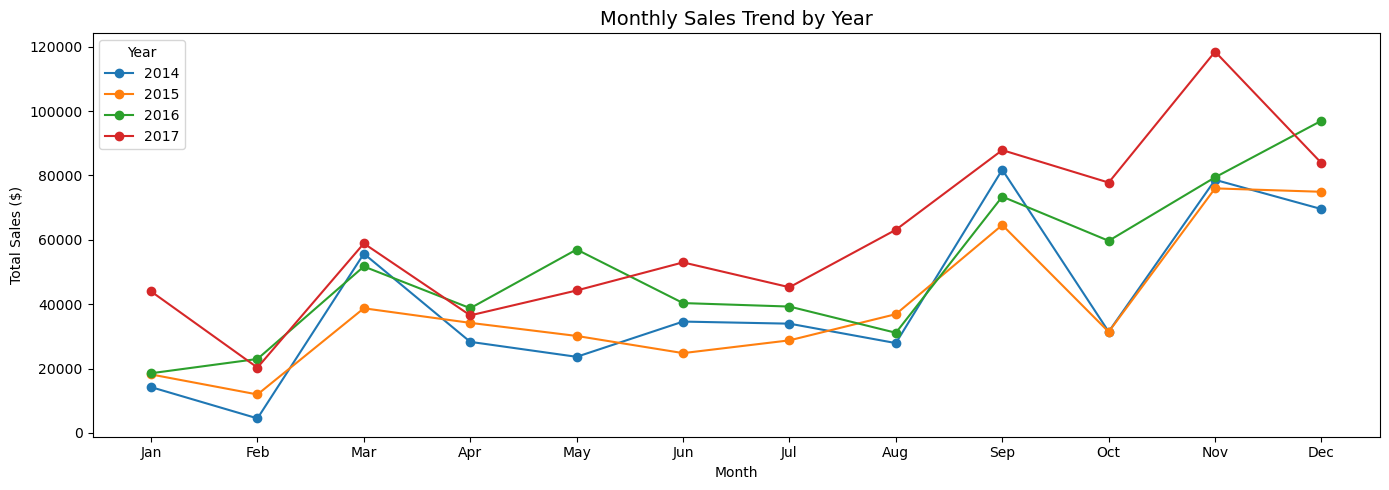

In [10]:
monthly = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
monthly['Date'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))

plt.figure(figsize=(14,5))
for yr, grp in monthly.groupby('Year'):
    plt.plot(grp['Month'], grp['Sales'], marker='o', label=str(yr))

plt.title('Monthly Sales Trend by Year', fontsize=14)

plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Year')
plt.tight_layout()
plt.savefig('../outputs/monthly_trend_by_year.png', dpi=150)
plt.show()

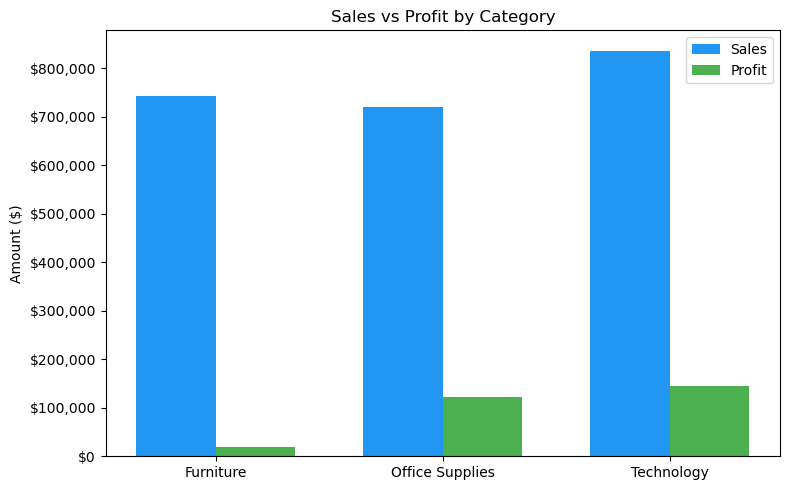

In [4]:
cat_summary = df.groupby('Category').agg(
    Total_Sales  = ('Sales',  'sum'),
    Total_Profit = ('Profit', 'sum')
).reset_index()

x = range(len(cat_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar([i - width/2 for i in x], cat_summary['Total_Sales'],  width, label='Sales',  color='#2196F3')
ax.bar([i + width/2 for i in x], cat_summary['Total_Profit'], width, label='Profit', color='#4CAF50')
ax.set_xticks(list(x))
ax.set_xticklabels(cat_summary['Category'])
ax.set_title('Sales vs Profit by Category')
ax.set_ylabel('Amount ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/category_sales_profit.png', dpi=150)
plt.show()

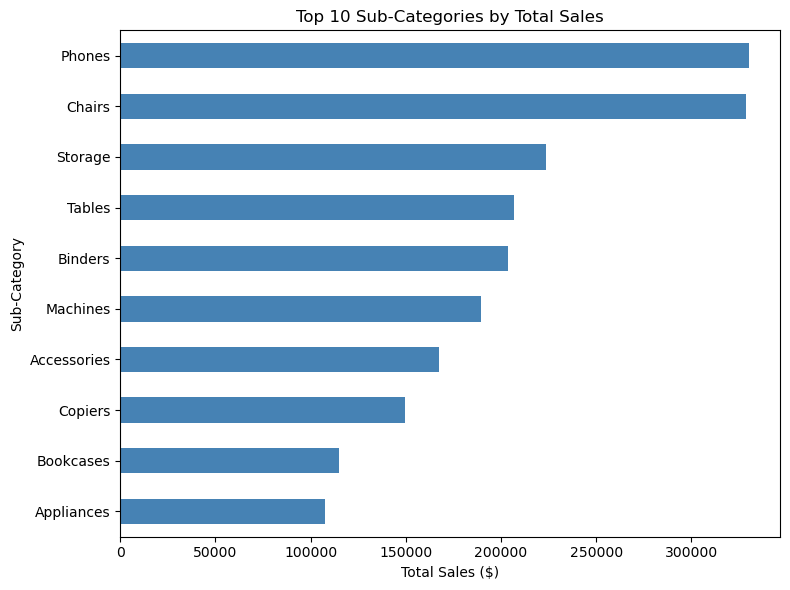

In [5]:
sub_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(8,6))
sub_sales.plot(kind='barh', color='steelblue')
plt.title('Top 10 Sub-Categories by Total Sales')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('../outputs/top_subcategories.png', dpi=150)
plt.show()

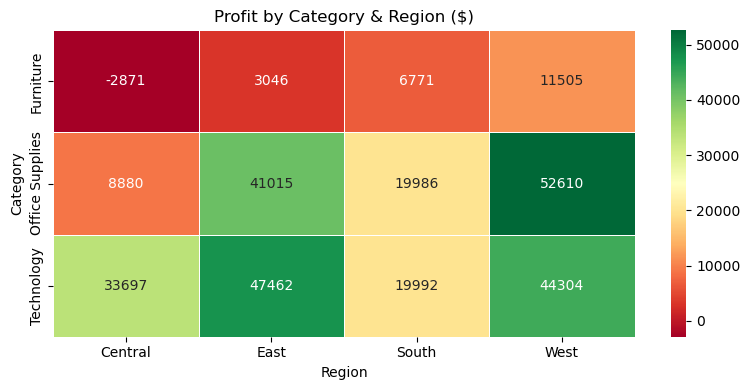

In [6]:
pivot = df.pivot_table(values='Profit', index='Category', columns='Region', aggfunc='sum')

plt.figure(figsize=(8,4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', linewidths=0.5)
plt.title('Profit by Category & Region ($)')
plt.tight_layout()
plt.savefig('../outputs/profit_heatmap.png', dpi=150)
plt.show()

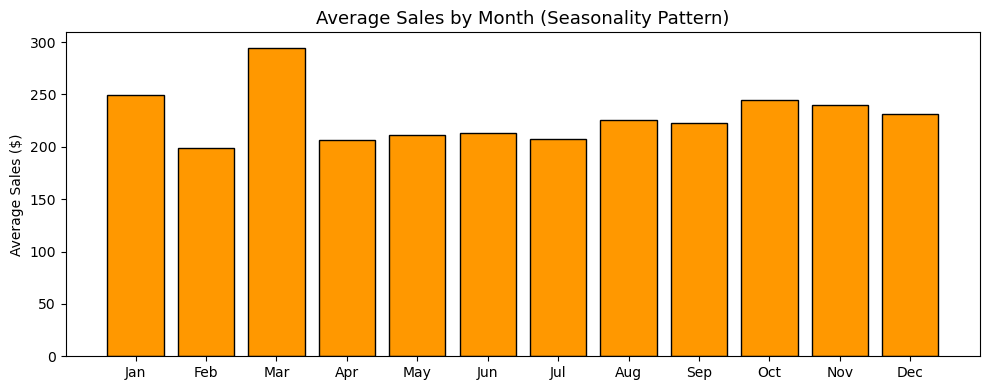

In [9]:
seasonal = df.groupby('Month')['Sales'].mean()
months   = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10,4))
plt.bar(months, seasonal.values, color='#FF9800', edgecolor='black')
plt.title('Average Sales by Month (Seasonality Pattern)', fontsize=13)
plt.ylabel('Average Sales ($)')
plt.tight_layout()
plt.savefig('../outputs/seasonality.png', dpi=150)
plt.show()

In [8]:
forecast = pd.read_csv('../outputs/sales_forecast.csv')

total_hist  = df['Sales'].sum()
total_profit = df['Profit'].sum()
margin       = (total_profit / total_hist) * 100
best_cat     = df.groupby('Category')['Sales'].sum().idxmax()
best_region  = df.groupby('Region')['Sales'].sum().idxmax()
next_month   = forecast['Forecasted_Sales_$'].iloc[0]

print("=" * 50)
print("     📋 BUSINESS SUMMARY REPORT")
print("=" * 50)
print(f"  Total Historical Sales  : ${total_hist:,.2f}")
print(f"  Total Profit            : ${total_profit:,.2f}")
print(f"  Overall Profit Margin   : {margin:.1f}%")
print(f"  Best Performing Category: {best_cat}")
print(f"  Best Performing Region  : {best_region}")
print(f"  Next Month Forecast     : ${next_month:,.2f}")
print("=" * 50)
print("\n📅 6-Month Forecast:")
for _, row in forecast.iterrows():
    print(f"   {row['Month']}  →  ${row['Forecasted_Sales_$']:,.2f}")
print("=" * 50)

     📋 BUSINESS SUMMARY REPORT
  Total Historical Sales  : $2,297,200.86
  Total Profit            : $286,397.02
  Overall Profit Margin   : 12.5%
  Best Performing Category: Technology
  Best Performing Region  : West
  Next Month Forecast     : $64,142.48

📅 6-Month Forecast:
   2018-01  →  $64,142.48
   2018-02  →  $64,027.73
   2018-03  →  $64,064.40
   2018-04  →  $63,665.44
   2018-05  →  $63,547.34
   2018-06  →  $64,374.55
